In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from analysis_functions import parse_ufloat
from uncertainties import unumpy as unp

# --- CSV datasets to plot (material string portion of filename) ---
csv_materials = [
    "steel",
    "100nm_SiC_coated_carbon_steel",
]

# --- Filtering thresholds ---
T_target = 550        # K
T_threshold = 100     # K — include points within T_target ± T_threshold
P_target = 400        # Torr
P_threshold = 400    # Torr — include points within P_target ± P_threshold

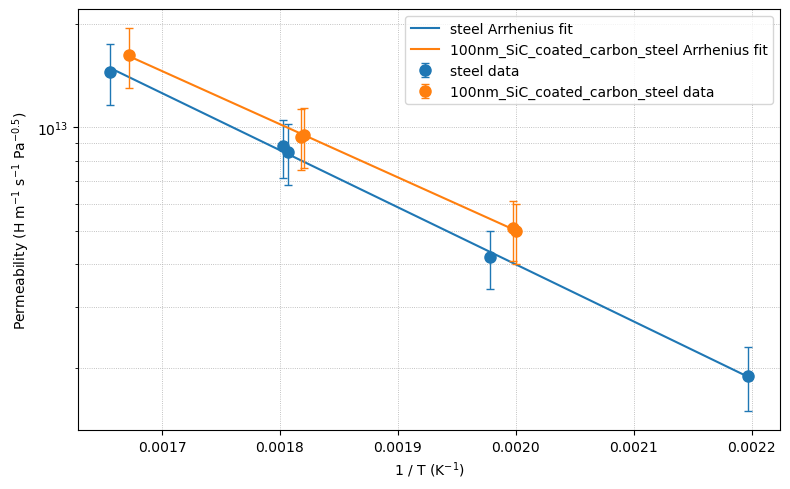

In [2]:
import os

fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.tab10.colors

for i, material_str in enumerate(csv_materials):
    csv_path = f"results/{material_str}_diffusivities.csv"
    df = pd.read_csv(csv_path)

    for col in ["Temperature (K)", "Upstream Pressure (Torr)", "Permeability"]:
        df[col] = df[col].apply(parse_ufloat)
    df = df.dropna(subset=["Temperature (K)", "Permeability"])

    # extract nominal T and P for filtering
    T_nom_all = np.array([t.n if hasattr(t, "n") else float(t) for t in df["Temperature (K)"]])
    P_nom_all = np.array([p.n if hasattr(p, "n") else float(p) for p in df["Upstream Pressure (Torr)"]])

    mask = (np.abs(T_nom_all - T_target) <= T_threshold) & (np.abs(P_nom_all - P_target) <= P_threshold)
    df = df[mask].copy()

    if len(df) == 0:
        print(f"WARNING: no points for {material_str} after filtering")
        continue

    T = df["Temperature (K)"].to_numpy()
    Phi = df["Permeability"].to_numpy()

    T_nom = unp.nominal_values(T)
    Phi_log = unp.log(Phi)
    yPhi = unp.nominal_values(Phi_log)
    yPhi_std = unp.std_devs(Phi_log)

    invT = 1.0 / T_nom
    Phi_nom = unp.nominal_values(Phi)
    Phi_std = unp.std_devs(Phi)

    # weighted Arrhenius fit
    wPhi = np.where((yPhi_std > 0) & np.isfinite(yPhi_std), 1.0 / yPhi_std, 1.0)
    Phi_coeffs = np.polyfit(invT, yPhi, 1, w=wPhi)
    fit_invT = np.linspace(invT.min(), invT.max(), 200)
    fit_Phi = np.exp(Phi_coeffs[0] * fit_invT + Phi_coeffs[1])

    color = colors[i % len(colors)]
    ax.errorbar(invT, Phi_nom, yerr=Phi_std, fmt="o", markersize=8,
                color=color, ecolor=color, elinewidth=1, capsize=3,
                label=f"{material_str} data")
    ax.plot(fit_invT, fit_Phi, "-", color=color, linewidth=1.5,
            label=f"{material_str} Arrhenius fit")

ax.set_yscale("log")
ax.set_xlabel("1 / T (K$^{-1}$)")
ax.set_ylabel("Permeability (H m$^{-1}$ s$^{-1}$ Pa$^{-0.5}$)")
ax.legend()
ax.grid(True, which="both", linestyle=":", linewidth=0.6)
plt.tight_layout()

save_dir = "results/figs/prf_analysis"
os.makedirs(save_dir, exist_ok=True)
fname = "_vs_".join(csv_materials) + f"_T{T_target}K_P{P_target}Torr.pdf"
fig.savefig(os.path.join(save_dir, fname))

plt.show()